In [1]:
library(ggplot2)
library(data.table)
theme_set(theme_bw())

# Source - https://stackoverflow.com/a
# Posted by dfrankow
# Retrieved 2026-01-16, License - CC BY-SA 3.0

options(repr.matrix.max.rows=600, repr.matrix.max.cols=200)
options(jupyter.plot_scale = 1)

In [8]:
tools = c('singlem', 'sylph', 'singlem_dev', 'singlem_joint_ee20bc')#, 'singlem_inject')
publication_names = data.table(
    tool = tools,
    publication_name = c('SingleM', 'sylph', 'SingleM dev', 'SingleM joint')#, 'SingleM inject')
)
communities = paste0('sample',as.character(c(0, 4, 5)))
skew = c("high_skew", "low_skew")
d1 = data.table(expand.grid(tool = tools, community = communities, skew = skew))
d1[, tool2 := publication_names[tool, on = "tool", publication_name]]
# output_singlem/opal/GCA_022615805.1_genomic.opal_report
readit = function(tool, community, skew){
    to_read = paste0('output_',tool,'/opal/', skew, '/', community,'.opal_report')
    return(fread(to_read))
}
d2 = d1[, readit(tool, community, skew), by=list(tool, community, skew, tool2)]

In [9]:
names(d2)

[1] "tool"      "community" "skew"      "tool2"     "tool"      "rank"     
[7] "metric"    "sample"    "value"

In [10]:
setnames(d2, c("tool"), c("tool1"))
setnames(d2, c("tool"), c("blah"))
setnames(d2, c("tool1"), c("tool"))
d3 = d2[blah != 'Gold standard', .(tool, community, skew, rank, metric, value, tool2)]
d3[, rank := factor(rank, c('kingdom','phylum','class','order','family','genus','species'))]

Warning message in setnames(d2, c("tool"), c("tool1")):
“Item 1 of 'old' is 'tool' which appears several times in column names. Just the first will be changed. There are 0 other items in 'old' that are also duplicated in column names.”


In [11]:
s1 = dcast(d3[!is.na(rank)], ...~metric, value.var='value')
s1[, c("tool", "tool2") := list(tool2, NULL)]

s1 = s1[order(rank, tool)]
fwrite(s1, 'opal_summary.csv', sep='\t')

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`).”


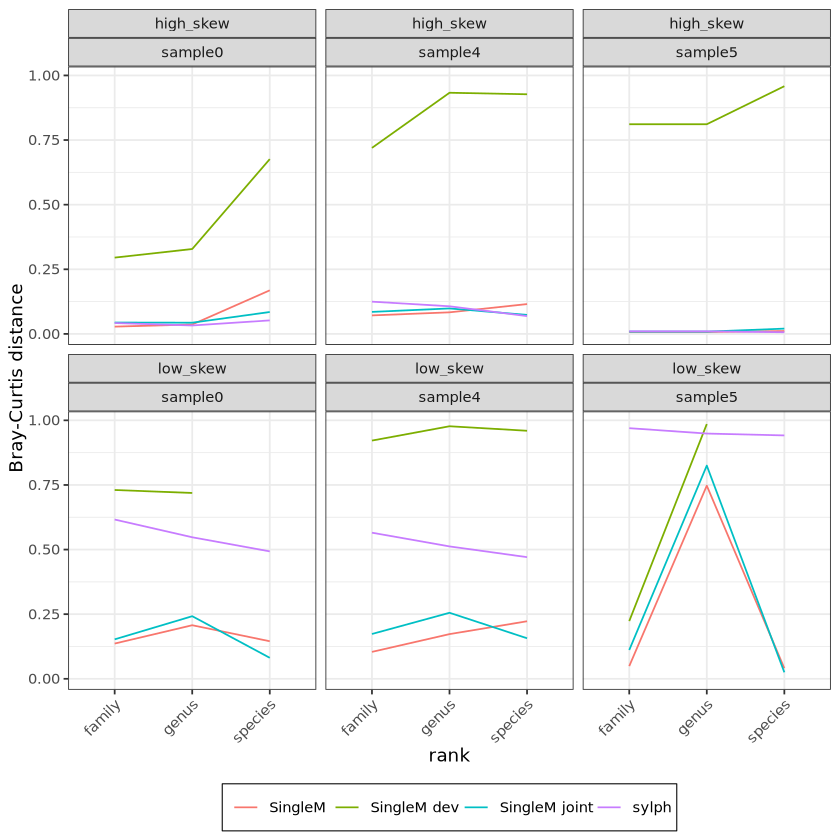

In [19]:
# Remove figure legend title, and put the legend in bottom left of plot, with a bounding box
ggplot(s1[rank %in% c("species", "genus", "family")],
       aes(rank, `Bray-Curtis distance`, group = tool, colour = tool)) +
   geom_line() +
   theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
   theme(legend.title=element_blank()) +
   theme(legend.position="bottom") +
   theme(legend.background = element_rect(colour = "black", linewidth = 0.3)) +
   facet_wrap(vars(skew, community))

# Relationship between relative abundance and accuracy

In [21]:
truth_profiles = data.table(expand.grid(community=communities, skew=skew))
truth_profiles2 = truth_profiles[
    ,
    fread(paste('truths/', skew, '/',community,'.condensed',sep=''),
          colClasses = c("coverage" = "double")),
    by=list(community, skew)
]
truth_profiles2[, c("sample", "tool") := .(NULL, 'Gold standard')]

In [22]:
tool_profiles = data.table(expand.grid(tool = tools, community = communities, skew = skew))
tool_profiles2 = tool_profiles[
    ,
    fread(paste('output_',tool,'/',tool,'/', skew, '/', community,'.profile',sep='')),
    by=list(tool, community, skew)
]
tool_profiles2[
    ,
    `:=`(sample = NULL,
         taxonomy = gsub('Root;','',gsub('; ',';',taxonomy)),
         tool = factor(publication_names[tool, on = "tool", publication_name]))
]

all_profiles = rbind(truth_profiles2, tool_profiles2)
all_profiles[, relabu := coverage / sum(coverage), by = list(community, skew, tool)]
m = dcast(all_profiles, taxonomy + community + skew ~ tool, value.var = c("relabu", "coverage"), fill = 0)
setnames(m, names(m), gsub("_", "__", names(m)))
setnames(m, c("relabu__Gold standard", "coverage__Gold standard"), c("true_relabu", "true_coverage"))

In [26]:
# singlem and sylph relative abundances
format_table <- function(m) {
    ra_cols <- grep("^relabu_|_relabu$", names(m), value = TRUE)
    mtmp = m[, which(!grepl("^coverage_|_coverage$", names(m))), with = FALSE]
    mtmp[
        ,
        c(ra_cols, "taxonomy") := c(
            lapply(.SD, scales::label_percent()),
            list(purrr::map_chr(strsplit(taxonomy, "; ?"), function(x) paste0(tail(x,2), collapse = "; ")))
        ),
        .SDcols = ra_cols
    ]
}

In [34]:
# singlem coverages
format_table_cov <- function(m) {
    cov_cols <- grep("^coverage_|_coverage$", names(m), value = TRUE)
    mtmp = m[, which(!grepl("^relabu_|_relabu$", names(m))), with = FALSE]
    mtmp[
        ,
        c(cov_cols, "taxonomy") := c(
            .SD,
            list(purrr::map_chr(strsplit(taxonomy, "; ?"), function(x) paste0(tail(x,2), collapse = "; ")))
        ),
        .SDcols = cov_cols
    ][order(community, skew, taxonomy)]
}

In [35]:
# kingdom
#format_table(m[grep("d__", taxonomy), lapply(.SD, sum), by = list(community, skew, taxonomy = gsub(";p__.*", "", taxonomy))])
format_table_cov(m[grep("d__", taxonomy), lapply(.SD, sum), by = list(community, skew, taxonomy = gsub(";p__.*", "", taxonomy))])

community,skew,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM joint,coverage__sylph
<fct>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample0,high_skew,d__Archaea,49.08141,49.75,52.37,49.82,52.484
sample0,high_skew,d__Bacteria,157.92681,159.49,155.85,157.12,157.314
sample0,low_skew,d__Archaea,2.90893,3.40,2.89,2.66,1.725
sample0,low_skew,d__Bacteria,204.09929,204.32,199.09,170.38,78.806
sample4,high_skew,d__Archaea,0.00000,0.00,0.32,0.00,0.000
sample4,high_skew,d__Bacteria,75.00000,71.40,69.37,70.68,68.600
sample4,low_skew,d__Archaea,3.00000,3.50,3.16,2.29,0.000
sample4,low_skew,d__Bacteria,72.00000,69.74,66.96,50.60,31.370
sample5,high_skew,d__Archaea,0.00000,0.00,12.35,0.00,0.000


In [36]:
# phylum
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";p__", taxonomy), lapply(.SD, sum), by = list(community, skew, taxonomy = gsub(";c__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";p__", taxonomy), lapply(.SD, sum), by = list(community, skew, taxonomy = gsub(";c__.*", "", taxonomy))])

community,skew,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM joint,coverage__sylph
<fct>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample0,high_skew,d__Bacteria; p__Actinobacteriota,24.46794,23.35,17.68,23.24,23.172
sample0,high_skew,d__Bacteria; p__Bacteroidota,11.04822,10.96,3.78,12.51,12.034
sample0,high_skew,d__Bacteria; p__Chloroflexota,1.14871,1.08,0.00,1.25,1.181
sample0,high_skew,d__Bacteria; p__Cyanobacteria,5.56396,5.80,0.00,4.08,2.915
sample0,high_skew,d__Bacteria; p__Desulfobacterota_I,3.79734,3.98,0.10,4.53,4.291
sample0,high_skew,d__Bacteria; p__Elusimicrobiota,2.75544,3.36,1.26,3.45,2.908
sample0,high_skew,d__Bacteria; p__Firmicutes,1.33633,1.25,0.00,1.77,1.415
sample0,high_skew,d__Bacteria; p__Firmicutes_A,4.36859,4.44,1.82,4.33,3.083
sample0,high_skew,d__Bacteria; p__Firmicutes_C,1.32777,1.19,0.00,1.32,1.313


In [12]:
# class
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";c__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";o__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";c__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";o__.*", "", taxonomy))])

community,known,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,0,p__Acidobacteriota; c__Holophagae,0.0,0.00,0.00,0.00,0.09,0.000
sample4,0,p__Acidobacteriota; c__UBA4820,3.0,2.96,0.10,2.97,3.20,0.000
sample4,0,p__Acidobacteriota; c__Vicinamibacteria,0.0,0.00,0.00,0.00,0.07,0.000
sample4,0,p__Actinobacteriota; c__Actinomycetia,39.0,37.41,31.74,37.41,4.66,9.555
sample4,0,p__Bacteroidota; c__Bacteroidia,6.0,5.51,1.12,5.52,7.76,0.000
sample4,0,p__Bacteroidota; c__Ignavibacteria,3.0,2.22,0.00,2.22,2.39,0.000
sample4,0,p__Bdellovibrionota; c__Bdellovibrionia,0.0,0.00,0.00,0.00,0.07,0.000
sample4,0,p__Campylobacterota; c__Campylobacteria,3.0,3.41,1.11,3.41,2.38,0.000
sample4,0,p__Chlamydiota; c__Chlamydiia,3.0,1.99,0.00,1.82,2.46,0.000


In [13]:
# order
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";o__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";f__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";o__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";f__.*", "", taxonomy))])

community,known,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,0,c__Actinomycetia; o__Mycobacteriales,3.0,2.84,0.00,2.84,0.99,0.000
sample4,0,c__Actinomycetia; o__Streptomycetales,36.0,31.29,26.76,31.29,3.67,9.555
sample4,0,c__Alphaproteobacteria; o__RF32,3.0,3.13,0.64,3.12,2.99,0.000
sample4,0,c__Bacteroidia; o__Bacteroidales,3.0,2.89,0.00,2.91,4.86,0.000
sample4,0,c__Bacteroidia; o__Cytophagales,0.0,0.00,0.00,0.00,0.07,0.000
sample4,0,c__Bacteroidia; o__Flavobacteriales,0.0,0.00,0.00,0.00,0.07,0.000
sample4,0,c__Bacteroidia; o__NS11-12g,3.0,1.99,0.00,1.98,2.55,0.000
sample4,0,c__Bacteroidia; o__Sphingobacteriales,0.0,0.00,0.00,0.00,0.21,0.000
sample4,0,c__Bdellovibrionia; o__Bdellovibrionales,0.0,0.00,0.00,0.00,0.07,0.000


In [14]:
# family
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";f__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";g__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";f__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";g__.*", "", taxonomy))])

community,known,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,0,o__4484-93; f__4484-93,0.0,0.00,0.00,0.00,0.07,0.000
sample4,0,o__Bacteroidales; f__Bacteroidaceae,3.0,2.26,0.00,2.26,3.03,0.000
sample4,0,o__Bacteroidales; f__F082,0.0,0.00,0.00,0.00,0.05,0.000
sample4,0,o__Bacteroidales; f__Marinifilaceae,0.0,0.00,0.00,0.00,0.09,0.000
sample4,0,o__Bacteroidales; f__Marinilabiliaceae,0.0,0.00,0.00,0.00,0.15,0.000
sample4,0,o__Bacteroidales; f__Muribaculaceae,0.0,0.00,0.00,0.00,0.71,0.000
sample4,0,o__Bacteroidales; f__Paludibacteraceae,0.0,0.00,0.00,0.00,0.41,0.000
sample4,0,o__Bacteroidales; f__Tannerellaceae,0.0,0.00,0.00,0.00,0.27,0.000
sample4,0,o__Bacteroidales; f__UBA7960,0.0,0.00,0.00,0.00,0.15,0.000


In [15]:
# How well does genus level rescue some of the missing genomes? First need to remake the table with genus level, annoying since kraken profiles are filled, when the rest aren't.
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";g__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";s__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";g__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";s__.*", "", taxonomy))])

community,known,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,0,f__2-02-FULL-66-22; g__2-02-FULL-66-22,0,0.00,0.00,0.00,0.07,0.000
sample4,0,f__4484-93; g__4484-93,0,0.00,0.00,0.00,0.07,0.000
sample4,0,f__Bacteroidaceae; g__Alloprevotella,0,0.00,0.00,0.00,0.55,0.000
sample4,0,f__Bacteroidaceae; g__Bacteroides,0,0.00,0.00,0.00,0.49,0.000
sample4,0,f__Bacteroidaceae; g__Bacteroides_G,0,0.00,0.00,0.00,0.06,0.000
sample4,0,f__Bacteroidaceae; g__Bacteroides_H,0,0.00,0.00,0.00,0.12,0.000
sample4,0,f__Bacteroidaceae; g__JAAYUD01,0,0.00,0.00,0.00,0.06,0.000
sample4,0,f__Bacteroidaceae; g__OM05-12,0,0.00,0.00,0.00,0.22,0.000
sample4,0,f__Bacteroidaceae; g__Phocaeicola,0,0.00,0.00,0.00,0.36,0.000


In [16]:
# Species level
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";s__", taxonomy)])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";s__", taxonomy)])

taxonomy,community,known,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
g__Actinomycetospora; s__Actinomycetospora chiangmaiensis,sample4,0,0e+00,0.00,0.00,0.00,0.23,0.000
g__Actinomycetospora; s__Actinomycetospora sp012933465,sample4,0,0e+00,0.72,0.00,0.72,0.34,0.000
g__BACL14; s__BACL14 sp000156155,sample4,0,0e+00,1.24,0.00,1.24,1.67,2.858
g__BACL14; s__BACL14 sp001044335,sample4,0,0e+00,0.00,0.00,0.00,0.27,0.000
g__BACL14; s__BACL14 sp010023085,sample4,0,0e+00,0.00,0.00,0.00,0.18,0.000
g__Caccovicinus; s__Caccovicinus sp910589195,sample4,0,0e+00,0.00,0.00,0.00,0.47,0.000
g__Streptomyces; s__Streptomyces paradoxus,sample4,0,0e+00,0.00,0.00,2.27,0.72,3.315
g__Streptomyces; s__Streptomyces somaliensis,sample4,0,0e+00,0.00,0.00,2.12,1.60,3.101
g__Streptomyces; s__Streptomyces sp008042275,sample4,0,0e+00,0.00,0.00,2.15,1.35,3.139
